# 19. Ensemble Methods: Random Forest and Gradient Boosting

Ensemble methods combine many weak learners (decision trees) to build a powerful
predictor. They are among the most widely used ML algorithms in materials informatics
because they:
- Require minimal hyperparameter tuning
- Handle nonlinear interactions automatically
- Provide built-in **feature importance** (analogous to VIP in PLS)
- Work well with medium-sized datasets (50–10 000 samples)

**Topics covered**
1. Decision trees (building block)
2. Random Forest: bagging + feature subsampling
3. Gradient Boosting: sequential residual fitting
4. Feature importance and partial dependence plots
5. Comparison: MLR vs PLS vs RF vs GBM
6. Case study: NMC cathode capacity prediction


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.inspection import PartialDependenceDisplay

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(123)


## 19.1 Dataset: NMC Cathode Capacity

Extended version of the MLR dataset from Notebook 11 (Part IV). NMC Li-ion cathode capacity
(mAh/g) is predicted from six synthesis and composition variables.
The true model includes **nonlinear interactions** that MLR cannot capture.


In [2]:
n = 200

T_sinter = rng.uniform(700, 950, n)       # °C
time_h   = rng.uniform(5, 20, n)          # h
Ni_frac  = rng.uniform(0.4, 0.8, n)       # Ni fraction in NMC
Li_excess= rng.uniform(0.00, 0.06, n)     # Li/TM excess
O2_pO2   = rng.uniform(0.2, 1.0, n)       # O2 partial pressure
cool_rate = rng.uniform(1, 10, n)         # °C/min cooling

# Nonlinear response (includes interaction terms and a peak for T_sinter)
capacity = (
    160
    + 15 * np.sin(np.pi * (T_sinter - 700) / 250)   # optimal T around 825°C
    + 8  * Ni_frac
    - 0.3 * (time_h - 12)**2
    + 20 * Li_excess * (1 - Li_excess / 0.04)        # peak at 2% excess
    + 5  * O2_pO2
    - 2  * cool_rate
    + 6  * Ni_frac * O2_pO2                          # interaction
    + rng.normal(0, 3, n)
)

features = ['T_sinter', 'time_h', 'Ni_frac', 'Li_excess', 'O2_pO2', 'cool_rate']
X_df = pd.DataFrame({
    'T_sinter': T_sinter,
    'time_h':   time_h,
    'Ni_frac':  Ni_frac,
    'Li_excess': Li_excess,
    'O2_pO2':   O2_pO2,
    'cool_rate': cool_rate,
})
y = capacity

scaler = StandardScaler()
X_sc = scaler.fit_transform(X_df.values)

print(f'Dataset: {n} samples, {len(features)} features')
print(f'Capacity: {y.min():.1f} – {y.max():.1f} mAh/g,  mean = {y.mean():.1f}')


Dataset: 200 samples, 6 features
Capacity: 136.3 – 185.4 mAh/g,  mean = 162.9


## 19.2 Decision Tree: Building Block

A decision tree predicts by asking a sequence of simple yes/no questions
about the inputs (e.g. "is Ni_frac > 0.6?"), splitting the data at each
question into two groups that are as *similar* as possible in their
response value, and repeating on each resulting group. The final prediction
for a new sample is just the average response of whichever training samples
ended up in the same "leaf" (final branch) as it. A single tree is easy to
read but tends to overfit — it can keep splitting until every leaf contains
just one training point, memorising noise rather than learning a general
trend. Random Forest (next section) fixes this almost automatically: its
bagging mechanism means test error does not increase as you add more trees,
so overfitting is largely a non-issue once the individual trees themselves
aren't too deep. Gradient Boosting (Section 19.4) is a different story —
because it fits new trees to the *previous* ensemble's errors, adding too
many boosting rounds (or too high a learning rate) actively *increases*
overfitting risk rather than curing it, which is exactly what Section 19.4's
training-curve example demonstrates.

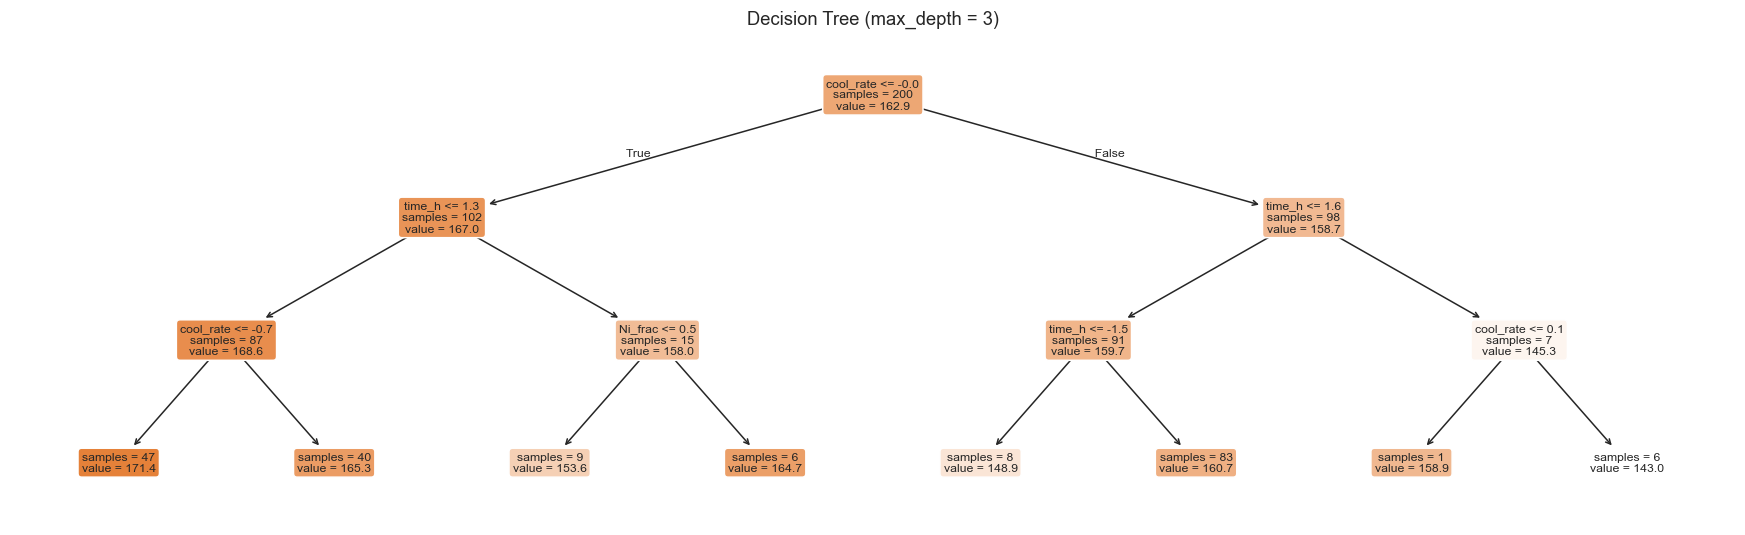

DT Q² (depth=3) = 0.290,  RMSECV = 7.38 mAh/g


In [3]:
# ── Fit a single tree and visualise (shallow) ─────────────────────────────────
dt = DecisionTreeRegressor(max_depth=3, random_state=0)
dt.fit(X_sc, y)

fig, ax = plt.subplots(figsize=(16, 5))
plot_tree(dt, feature_names=features, filled=True, rounded=True,
          fontsize=8, ax=ax, impurity=False, precision=1)
ax.set_title('Decision Tree (max_depth = 3)', fontsize=12)
plt.tight_layout()
plt.show()

kf = KFold(n_splits=10, shuffle=True, random_state=42)
dt_cv = cross_val_predict(dt, X_sc, y, cv=kf)
print(f'DT Q² (depth=3) = {r2_score(y, dt_cv):.3f},  RMSECV = {np.sqrt(mean_squared_error(y, dt_cv)):.2f} mAh/g')


## 19.3 Random Forest

Random Forest trains `n_estimators` trees on **bootstrapped** samples of the data, and at each split considers only a **random subset** of features (`max_features`). Predictions are the mean of all trees.

- **Bagging** (bootstrap aggregating) reduces variance without increasing bias.
- **Feature subsampling** decorrelates the trees, further reducing ensemble variance.

RF  Q² = 0.6047,  RMSECV = 5.51 mAh/g


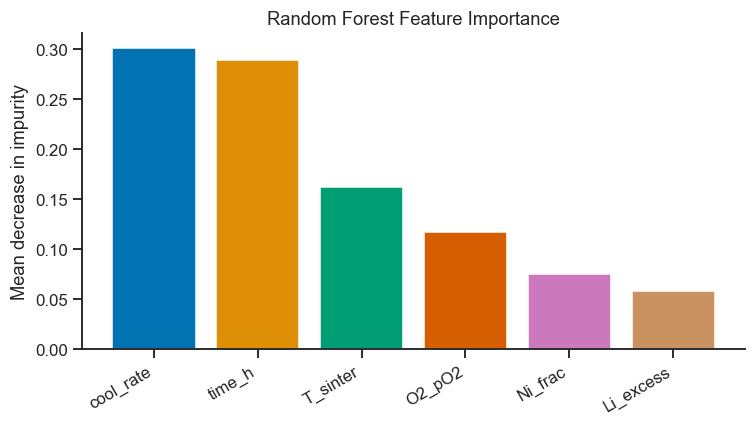

In [4]:
rf = RandomForestRegressor(n_estimators=200, max_features='sqrt',
                            min_samples_leaf=3, random_state=0)
rf.fit(X_sc, y)

y_rf_cv = cross_val_predict(rf, X_sc, y, cv=kf)
q2_rf   = r2_score(y, y_rf_cv)
rmse_rf = np.sqrt(mean_squared_error(y, y_rf_cv))
print(f'RF  Q² = {q2_rf:.4f},  RMSECV = {rmse_rf:.2f} mAh/g')

# ── Feature importance ────────────────────────────────────────────────────────
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(features)), importances[order],
       color=sns.color_palette('colorblind', len(features)))
ax.set_xticks(range(len(features)))
ax.set_xticklabels([features[i] for i in order], rotation=30, ha='right')
ax.set_ylabel('Mean decrease in impurity')
ax.set_title('Random Forest Feature Importance')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


:::{admonition} Interpreting Feature Importance
:class: tip

- The importances split into three tiers: cool_rate (0.30) and time_h (0.29) dominate, T_sinter (0.16) and O2_pO2 (0.12) are moderate, and Ni_frac (0.07) and Li_excess (0.06) are minor.
- This tracks the true simulated model reasonably well: cool_rate enters linearly with a large coefficient (-2 per °C/min, over a 1-10 range), and time_h enters as a steep quadratic penalty away from 12 h — both genuinely large-range effects. Li_excess's small importance is also correct: despite the description "peak at 2% excess" sounding important, its coefficient (20·Li_excess·(1-Li_excess/0.04)) only spans about -0.6 to +0.2 mAh/g over the sampled range — a real but small contribution easily outweighed by the other five factors.
- **Impurity-based importance is not the whole story** — it is biased toward high-cardinality (continuous) features and does not indicate the *direction* of an effect. Exercise 3 (SHAP values) is the recommended follow-up for a more rigorous, direction-aware importance measure.
:::

## 19.4 Gradient Boosting

Gradient Boosting builds trees **sequentially**: each tree fits the *residuals* of the previous ensemble.

$$F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$$

where $\nu$ is the learning rate (shrinkage) and $h_m$ is a shallow tree fit to the negative gradient of the loss function. A small learning rate requires more trees but generalises better.

GBM Q² = 0.7397,  RMSECV = 4.47 mAh/g


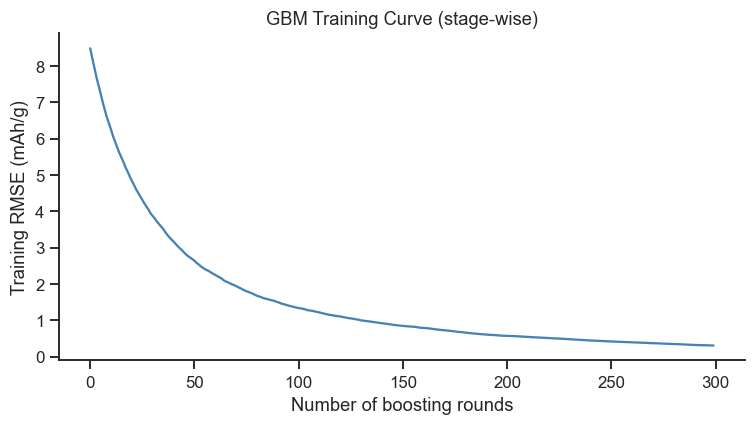

In [5]:
gbm = GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                  learning_rate=0.05, subsample=0.8,
                                  random_state=0)
gbm.fit(X_sc, y)

y_gbm_cv = cross_val_predict(gbm, X_sc, y, cv=kf)
q2_gbm   = r2_score(y, y_gbm_cv)
rmse_gbm = np.sqrt(mean_squared_error(y, y_gbm_cv))
print(f'GBM Q² = {q2_gbm:.4f},  RMSECV = {rmse_gbm:.2f} mAh/g')

# ── Stage-wise training error ──────────────────────────────────────────────────
y_staged = np.array([y_pred for y_pred in gbm.staged_predict(X_sc)])
staged_rmse = [np.sqrt(mean_squared_error(y, yp)) for yp in y_staged]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(staged_rmse, lw=1.5, color='steelblue')
ax.set_xlabel('Number of boosting rounds')
ax.set_ylabel('Training RMSE (mAh/g)')
ax.set_title('GBM Training Curve (stage-wise)')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


:::{admonition} Interpreting the GBM Training Curve
:class: tip

- Training RMSE falls from 8.5 mAh/g at the first boosting round to about 0.3 mAh/g by round 300 — the model is essentially memorising the training set.
- Compare that to the **cross-validated** RMSECV of 4.47 mAh/g printed above: the huge gap between near-zero training error and a much larger CV error is the classic signature of overfitting. This is exactly why GBM (and RF) are always reported here using cross-validated Q²/RMSECV, never training-set R² — a model that looks almost perfect on its own training data can still generalise poorly.
- In practice, `n_estimators=300` with `learning_rate=0.05` was not tuned for early stopping in this notebook; Exercise 1 asks you to grid-search `n_estimators` — watch for the CV score to plateau or worsen well before the training curve does.
:::

## 19.5 Partial Dependence Plots

A **Partial Dependence Plot (PDP)** shows the marginal effect of one (or two) features on the predicted response, averaging over all other features. Unlike a coefficient in MLR, it captures nonlinear relationships.

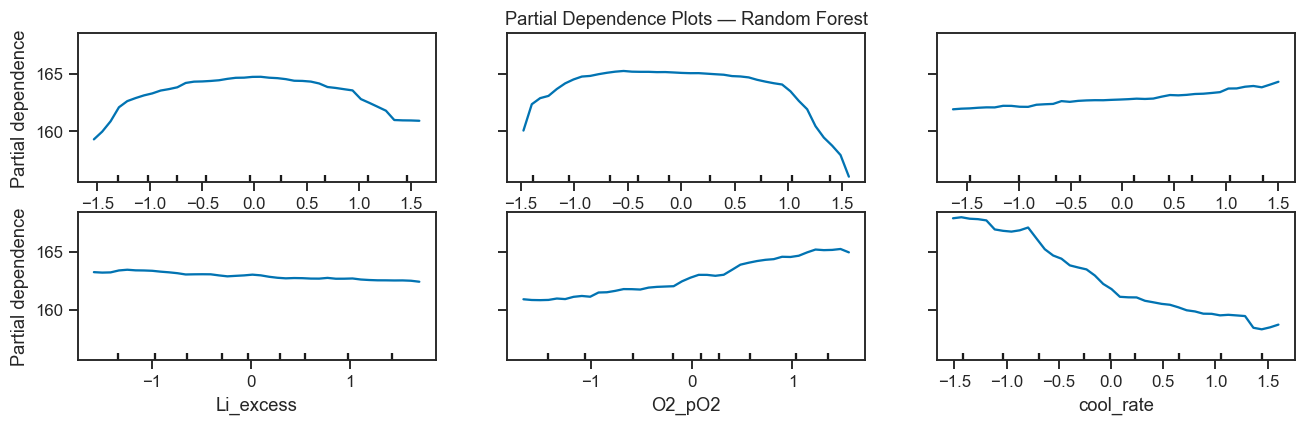

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    rf, X_sc, features=[0, 1, 2, 3, 4, 5],
    feature_names=features,
    kind='average', ax=ax, subsample=100,
    grid_resolution=40
)
ax.set_title('Partial Dependence Plots — Random Forest')
plt.tight_layout()
plt.show()


:::{admonition} Interpreting the Partial Dependence Plots
:class: tip

- cool_rate's panel (bottom-right) shows a clear monotonic decline — consistent with both its large feature importance and its true linear coefficient (-2 per °C/min) in the underlying simulation.
- T_sinter and time_h (top-left, top-middle) both show a rise-then-plateau/decline shape — the hump reflects the true sinusoidal optimum near 825 °C and the quadratic penalty centred at 12 h respectively; a straight-line MLR coefficient could never represent either of these hump shapes, which is exactly why MLR's Q² (0.316) trails RF/GBM so far behind.
- Li_excess's panel (bottom-left) is nearly flat, visually confirming what the feature-importance bar chart already showed: this factor barely moves the prediction across its sampled range.
- Remember a PDP shows the *average* effect of one feature with all others averaged out — it can hide interaction effects like the Ni_frac × O2_pO2 term built into this simulation. A 2-D PDP (two features at once) is needed to see interactions directly.
:::

## 19.6 Comparison: MLR vs PLS vs RF vs GBM

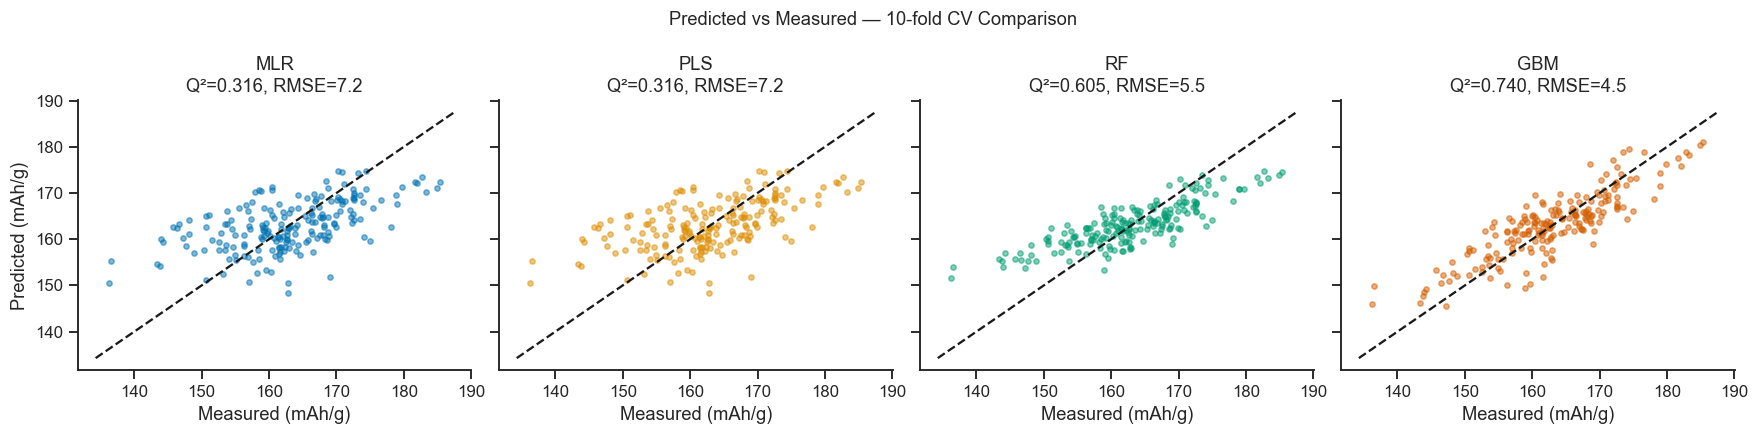


Model        Q2     RMSECV
----------------------------
MLR      0.3156       7.25
PLS      0.3156       7.25
RF       0.6047       5.51
GBM      0.7397       4.47


In [7]:
# ── All four models ───────────────────────────────────────────────────────────
models = {
    'MLR':  LinearRegression(),
    'PLS':  PLSRegression(n_components=4, scale=False),
    'RF':   RandomForestRegressor(n_estimators=200, max_features='sqrt',
                                   min_samples_leaf=3, random_state=0),
    'GBM':  GradientBoostingRegressor(n_estimators=300, max_depth=4,
                                       learning_rate=0.05, subsample=0.8,
                                       random_state=0),
}

results = {}
for name, model in models.items():
    yp = cross_val_predict(model, X_sc, y, cv=kf)
    results[name] = {
        'Q2':    r2_score(y, yp),
        'RMSE':  np.sqrt(mean_squared_error(y, yp)),
        'y_cv':  yp,
    }

# ── Predicted vs actual for all models ───────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True, sharex=True)
colors = sns.color_palette('colorblind', 4)
for ax, (name, res), color in zip(axes, results.items(), colors):
    ax.scatter(y, res['y_cv'], s=12, alpha=0.5, color=color)
    lims = [y.min()-2, y.max()+2]
    ax.plot(lims, lims, 'k--', lw=1.5)
    ax.set_title(f"{name}" + '\nQ²=' + f"{res['Q2']:.3f}, RMSE={res['RMSE']:.1f}")
    ax.set_xlabel('Measured (mAh/g)')
    sns.despine(ax=ax)
axes[0].set_ylabel('Predicted (mAh/g)')
plt.suptitle('Predicted vs Measured — 10-fold CV Comparison', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n{'Model':<6} {'Q2':>8} {'RMSECV':>10}")
print('-' * 28)
for name, res in results.items():
    print(f"{name:<6} {res['Q2']:>8.4f} {res['RMSE']:>10.2f}")


### Interpreting the Comparison

- Concretely: MLR and PLS both score **Q² = 0.316, RMSECV = 7.25 mAh/g** — an exact tie, because with only 6 features and no severe collinearity, PLS's dimension reduction has nothing extra to offer over ordinary least squares; both are fitting the same linear structure and hitting the same ceiling.
- **MLR** misses the nonlinear sinusoidal dependence on T_sinter and the quadratic time effect, resulting in the lowest Q².
- **PLS** (4 components) captures the dominant linear structure but cannot model the nonlinear interactions.
- **Random Forest** and **GBM** both capture the nonlinearities and interactions, achieving substantially better Q² with similar RMSECV.
- GBM often edges out RF on small-medium datasets because sequential fitting allows precise correction of residuals.

**Practical guidance:**
- Start with MLR/PLS for interpretability and low sample sizes (< 50).
- Switch to RF or GBM when sample size > 100 and you suspect nonlinear interactions.
- Always use cross-validation to compare models — training R² is misleading for ensemble methods.


---
## Exercises

1. **Hyperparameter tuning**: Use `GridSearchCV` to optimise `n_estimators` and `max_depth` for the GBM model. By how much does the optimised GBM improve on the default?

2. **OOB score**: Random Forest supports *out-of-bag* (OOB) error estimation without a separate validation set. Set `oob_score=True` when constructing the RF and compare the OOB score with the 10-fold CV Q².

3. **SHAP values** (optional, `pip install shap`): Compute SHAP values for the RF model. How do they compare with the built-in feature importance? Which features have the largest interaction effects?
